# N1 - Logistic Regression

**Models**:
1. **Baseline 1 + is_evening**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with is_evening)
2. **Baseline 1 + hour_sin_cos**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with hour_sin/cos)
3. **Baseline 2 + is_evening**: PhoBERT-v2-Finetuned + Handcraft (with is_evening)
4. **Baseline 2 + hour_sin_cos**: PhoBERT-v2-Finetuned + Handcraft (with hour_sin/cos)

**Evaluation**: 10-Fold CV → Paired T-Test
**Metrics**: AUC, F1, Precision, Recall
**Final Model**: Trained on full data with optimal threshold

In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve
)

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\Vietnamese-Fake-News-Detection


In [19]:
# Paths
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
TRAINED_DIR = PROJECT_ROOT / 'data' / 'trained' / 'early_fusion'
MODEL_DIR = PROJECT_ROOT / 'model' / 'early_fusion' / 'logistic_regression'
FIGURES_DIR = PROJECT_ROOT / 'data' / 'figures' / 'training'

# Ensure directories exist
TRAINED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random state
RANDOM_STATE = 42
N_FOLDS = 10

## 1. Load Data

In [20]:
# Load CSV with labels and handcraft features
df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values

print(f"Samples: {len(df)}")
print(f"Label distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736
Label distribution: {0: 3929, 1: 807}


In [21]:
# Load selected features
with open(ANALYSIS_DIR / 'selected_features.txt', 'r') as f:
    all_features = [line.strip() for line in f.readlines()]

print(f"All selected features ({len(all_features)}): {all_features}")

# Split into two variants
# Variant 1: with is_evening (exclude hour_sin, hour_cos)
features_is_evening = [f for f in all_features if f not in ['feat_hour_sin', 'feat_hour_cos']]

# Variant 2: with hour_sin/cos (exclude is_evening)
features_hour_sin_cos = [f for f in all_features if f != 'feat_is_evening']

print(f"\nFeatures with is_evening ({len(features_is_evening)}): {features_is_evening}")
print(f"Features with hour_sin_cos ({len(features_hour_sin_cos)}): {features_hour_sin_cos}")

All selected features (12): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_hour_cos', 'feat_hour_sin', 'feat_is_evening', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']

Features with is_evening (10): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_is_evening', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']
Features with hour_sin_cos (11): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_hour_cos', 'feat_hour_sin', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']


In [22]:
# Load embeddings
phobert_pretrain = np.load(ENCODED_DIR / 'phobertv2' / 'pretrained_embeddings.npy')
phobert_finetune = np.load(ENCODED_DIR / 'phobertv2' / 'finetuned_embeddings.npy')
tfidf_emb = np.load(ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy')

print(f"PhoBERT pretrained: {phobert_pretrain.shape}")
print(f"PhoBERT finetuned: {phobert_finetune.shape}")
print(f"TF-IDF: {tfidf_emb.shape}")

# Handcraft features
handcraft_is_evening = df[features_is_evening].values
handcraft_hour_sin_cos = df[features_hour_sin_cos].values

print(f"\nHandcraft (is_evening): {handcraft_is_evening.shape}")
print(f"Handcraft (hour_sin_cos): {handcraft_hour_sin_cos.shape}")

PhoBERT pretrained: (4736, 88)
PhoBERT finetuned: (4736, 68)
TF-IDF: (4736, 120)

Handcraft (is_evening): (4736, 10)
Handcraft (hour_sin_cos): (4736, 11)


## 2. Define Model Configurations

In [23]:
# Model configurations
MODEL_CONFIGS = {
    'B1_is_evening': {
        'name': 'Baseline1 + is_evening',
        'baseline': 1,
        'time_type': 'is_evening',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening
    },
    'B1_hour_sin_cos': {
        'name': 'Baseline1 + hour_sin_cos',
        'baseline': 1,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos
    },
    'B2_is_evening': {
        'name': 'Baseline2 + is_evening',
        'baseline': 2,
        'time_type': 'is_evening',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening
    },
    'B2_hour_sin_cos': {
        'name': 'Baseline2 + hour_sin_cos',
        'baseline': 2,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos
    }
}

print("Model configurations:")
for key, config in MODEL_CONFIGS.items():
    total_dim = sum(e.shape[1] for e in config['embeddings']) + config['handcraft'].shape[1]
    print(f"  {key}: {config['name']} → {total_dim} dims")

Model configurations:
  B1_is_evening: Baseline1 + is_evening → 218 dims
  B1_hour_sin_cos: Baseline1 + hour_sin_cos → 219 dims
  B2_is_evening: Baseline2 + is_evening → 78 dims
  B2_hour_sin_cos: Baseline2 + hour_sin_cos → 79 dims


## 3. Evaluation Functions

In [24]:
def prepare_features(config):
    """Concatenate embeddings and handcraft features"""
    parts = config['embeddings'] + [config['handcraft']]
    return np.hstack(parts)

def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

def evaluate_fold(y_true, y_prob, threshold=0.5):
    """Calculate metrics for a fold"""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'threshold': threshold
    }

In [25]:
def train_evaluate_cv(X, y, n_folds=10, random_state=42):
    """Train and evaluate with K-Fold CV, find optimal threshold"""
    kf = StratifiedKFold(n_splits=n_folds, shuffle=False)
    fold_results = []
    all_y_true = []
    all_y_prob = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Train model
        model = LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=random_state,
            solver='lbfgs'
        )
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
        
        # Find optimal threshold on validation set
        opt_threshold = find_optimal_threshold(y_val, y_prob)
        
        # Evaluate
        metrics = evaluate_fold(y_val, y_prob, opt_threshold)
        metrics['fold'] = fold + 1
        fold_results.append(metrics)
        
        all_y_true.extend(y_val)
        all_y_prob.extend(y_prob)
    
    return fold_results, np.array(all_y_true), np.array(all_y_prob)

In [26]:
def train_final_model(X, y, random_state=42):
    """Train final model on full data"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=random_state,
        solver='lbfgs'
    )
    model.fit(X_scaled, y)
    
    # Find optimal threshold on training data
    y_prob = model.predict_proba(X_scaled)[:, 1]
    opt_threshold = find_optimal_threshold(y, y_prob)
    
    return model, scaler, opt_threshold

## 4. Train All Models

In [27]:
# Store results
all_results = {}
all_fold_metrics = {}

for model_key, config in tqdm(MODEL_CONFIGS.items(), desc="Training models"):
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")
    
    # Prepare features
    X = prepare_features(config)
    y = labels
    print(f"Feature shape: {X.shape}")
    
    # 10-Fold CV
    fold_results, y_true_all, y_prob_all = train_evaluate_cv(
        X, y, n_folds=N_FOLDS, random_state=RANDOM_STATE
    )
    
    # Calculate mean metrics
    fold_df = pd.DataFrame(fold_results)
    mean_metrics = {
        'auc_mean': fold_df['auc'].mean(),
        'auc_std': fold_df['auc'].std(),
        'f1_mean': fold_df['f1'].mean(),
        'f1_std': fold_df['f1'].std(),
        'precision_mean': fold_df['precision'].mean(),
        'precision_std': fold_df['precision'].std(),
        'recall_mean': fold_df['recall'].mean(),
        'recall_std': fold_df['recall'].std(),
        'threshold_mean': fold_df['threshold'].mean()
    }
    
    print(f"\n10-Fold CV Results:")
    print(f"  AUC:       {mean_metrics['auc_mean']:.4f} ± {mean_metrics['auc_std']:.4f}")
    print(f"  F1:        {mean_metrics['f1_mean']:.4f} ± {mean_metrics['f1_std']:.4f}")
    print(f"  Precision: {mean_metrics['precision_mean']:.4f} ± {mean_metrics['precision_std']:.4f}")
    print(f"  Recall:    {mean_metrics['recall_mean']:.4f} ± {mean_metrics['recall_std']:.4f}")
    print(f"  Threshold: {mean_metrics['threshold_mean']:.4f}")
    
    # Train final model on full data
    final_model, scaler, opt_threshold = train_final_model(X, y, RANDOM_STATE)
    print(f"\nFinal model optimal threshold: {opt_threshold:.4f}")
    
    # Save fold results for paired t-test
    all_fold_metrics[model_key] = fold_df
    all_results[model_key] = {
        'config': config['name'],
        'baseline': config['baseline'],
        'time_type': config['time_type'],
        'mean_metrics': mean_metrics,
        'fold_results': fold_results,
        'model': final_model,
        'scaler': scaler,
        'threshold': opt_threshold,
        'feature_names': config['feature_names']
    }

Training models:   0%|          | 0/4 [00:00<?, ?it/s]


Training: Baseline1 + is_evening
Feature shape: (4736, 218)


Training models:  25%|██▌       | 1/4 [00:00<00:01,  2.09it/s]


10-Fold CV Results:
  AUC:       0.9377 ± 0.0078
  F1:        0.7358 ± 0.0181
  Precision: 0.7204 ± 0.0733
  Recall:    0.7632 ± 0.0634
  Threshold: 0.7341

Final model optimal threshold: 0.7079

Training: Baseline1 + hour_sin_cos
Feature shape: (4736, 219)


Training models:  50%|█████     | 2/4 [00:00<00:00,  2.14it/s]


10-Fold CV Results:
  AUC:       0.9385 ± 0.0072
  F1:        0.7383 ± 0.0236
  Precision: 0.7327 ± 0.0865
  Recall:    0.7620 ± 0.0895
  Threshold: 0.7361

Final model optimal threshold: 0.7811

Training: Baseline2 + is_evening
Feature shape: (4736, 78)


Training models:  75%|███████▌  | 3/4 [00:01<00:00,  2.84it/s]


10-Fold CV Results:
  AUC:       0.9765 ± 0.0072
  F1:        0.8835 ± 0.0205
  Precision: 0.8711 ± 0.0499
  Recall:    0.8997 ± 0.0400
  Threshold: 0.7474

Final model optimal threshold: 0.6837

Training: Baseline2 + hour_sin_cos
Feature shape: (4736, 79)


Training models: 100%|██████████| 4/4 [00:01<00:00,  2.59it/s]


10-Fold CV Results:
  AUC:       0.9770 ± 0.0068
  F1:        0.8776 ± 0.0199
  Precision: 0.8738 ± 0.0535
  Recall:    0.8848 ± 0.0339
  Threshold: 0.7803

Final model optimal threshold: 0.7206


## 5. Save Fold Results & Models

In [28]:
# Save fold results for paired t-test
for model_key, fold_df in all_fold_metrics.items():
    output_path = TRAINED_DIR / f'logreg_{model_key}_folds.csv'
    fold_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

# Save final models
for model_key, result in all_results.items():
    model_path = MODEL_DIR / f'{model_key}_model.joblib'
    joblib.dump({
        'model': result['model'],
        'scaler': result['scaler'],
        'threshold': result['threshold'],
        'feature_names': result['feature_names'],
        'config': result['config']
    }, model_path)
    print(f"Saved: {model_path}")

Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\logreg_B1_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\logreg_B1_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\logreg_B2_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\logreg_B2_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\logistic_regression\B1_is_evening_model.joblib
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\logistic_regression\B1_hour_sin_cos_model.joblib
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\logistic_regression\B2_is_evening_model.joblib
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\logistic_regression\B2_hour_sin_cos_model.joblib


## 6. Summary Table

In [29]:
# Create summary table
summary_data = []
for model_key, result in all_results.items():
    m = result['mean_metrics']
    summary_data.append({
        'Model': result['config'],
        'Baseline': result['baseline'],
        'Time Feature': result['time_type'],
        'AUC': f"{m['auc_mean']:.4f}±{m['auc_std']:.4f}",
        'F1': f"{m['f1_mean']:.4f}±{m['f1_std']:.4f}",
        'Precision': f"{m['precision_mean']:.4f}±{m['precision_std']:.4f}",
        'Recall': f"{m['recall_mean']:.4f}±{m['recall_std']:.4f}",
        'Threshold': f"{result['threshold']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY - LOGISTIC REGRESSION")
print("="*100)
display(summary_df)


SUMMARY - LOGISTIC REGRESSION


,Model,Baseline,Time Feature,AUC,F1,Precision,Recall,Threshold
0,Baseline1 + is_evening,1,is_evening,0.9377±0.0078,0.7358±0.0181,0.7204±0.0733,0.7632±0.0634,0.7079
1,Baseline1 + hour_sin_cos,1,hour_sin_cos,0.9385±0.0072,0.7383±0.0236,0.7327±0.0865,0.7620±0.0895,0.7811
2,Baseline2 + is_evening,2,is_evening,0.9765±0.0072,0.8835±0.0205,0.8711±0.0499,0.8997±0.0400,0.6837
3,Baseline2 + hour_sin_cos,2,hour_sin_cos,0.9770±0.0068,0.8776±0.0199,0.8738±0.0535,0.8848±0.0339,0.7206


## 7. Paired T-Test Analysis

In [30]:
def paired_ttest(fold_df1, fold_df2, metric='f1'):
    """Perform paired t-test between two models"""
    scores1 = fold_df1[metric].values
    scores2 = fold_df2[metric].values
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    return t_stat, p_value, scores1.mean() - scores2.mean()

# Valid comparison pairs:
# 1. Same baseline, different time feature
# 2. Different baseline, same number of handcraft features
COMPARISON_PAIRS = [
    # Same baseline comparisons
    ('B1_is_evening', 'B1_hour_sin_cos', 'Baseline 1: is_evening vs hour_sin_cos'),
    ('B2_is_evening', 'B2_hour_sin_cos', 'Baseline 2: is_evening vs hour_sin_cos'),
    # Cross-baseline with same handcraft count
    ('B1_is_evening', 'B2_is_evening', 'is_evening: Baseline 1 vs Baseline 2'),
    ('B1_hour_sin_cos', 'B2_hour_sin_cos', 'hour_sin_cos: Baseline 1 vs Baseline 2'),
]

print("Paired T-Test Results (F1 Score):")
print("="*80)

ttest_results = []
for model1, model2, desc in COMPARISON_PAIRS:
    t_stat, p_value, diff = paired_ttest(
        all_fold_metrics[model1], 
        all_fold_metrics[model2], 
        metric='f1'
    )
    sig = "*" if p_value < 0.05 else ""
    print(f"\n{desc}")
    print(f"  t-stat: {t_stat:.4f}, p-value: {p_value:.4f} {sig}")
    print(f"  Mean diff: {diff:.4f} ({'model1 better' if diff > 0 else 'model2 better'})")
    
    ttest_results.append({
        'comparison': desc,
        'model1': model1,
        'model2': model2,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'mean_diff': diff
    })

Paired T-Test Results (F1 Score):

Baseline 1: is_evening vs hour_sin_cos
  t-stat: -0.8948, p-value: 0.3942 
  Mean diff: -0.0025 (model2 better)

Baseline 2: is_evening vs hour_sin_cos
  t-stat: 2.0809, p-value: 0.0672 
  Mean diff: 0.0059 (model1 better)

is_evening: Baseline 1 vs Baseline 2
  t-stat: -17.5204, p-value: 0.0000 *
  Mean diff: -0.1477 (model2 better)

hour_sin_cos: Baseline 1 vs Baseline 2
  t-stat: -16.9572, p-value: 0.0000 *
  Mean diff: -0.1393 (model2 better)


In [31]:
# Save t-test results
ttest_df = pd.DataFrame(ttest_results)
ttest_df.to_csv(TRAINED_DIR / 'logreg_paired_ttest.csv', index=False)
print(f"\nSaved: {TRAINED_DIR / 'logreg_paired_ttest.csv'}")


Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\logreg_paired_ttest.csv


## 8. Visualizations

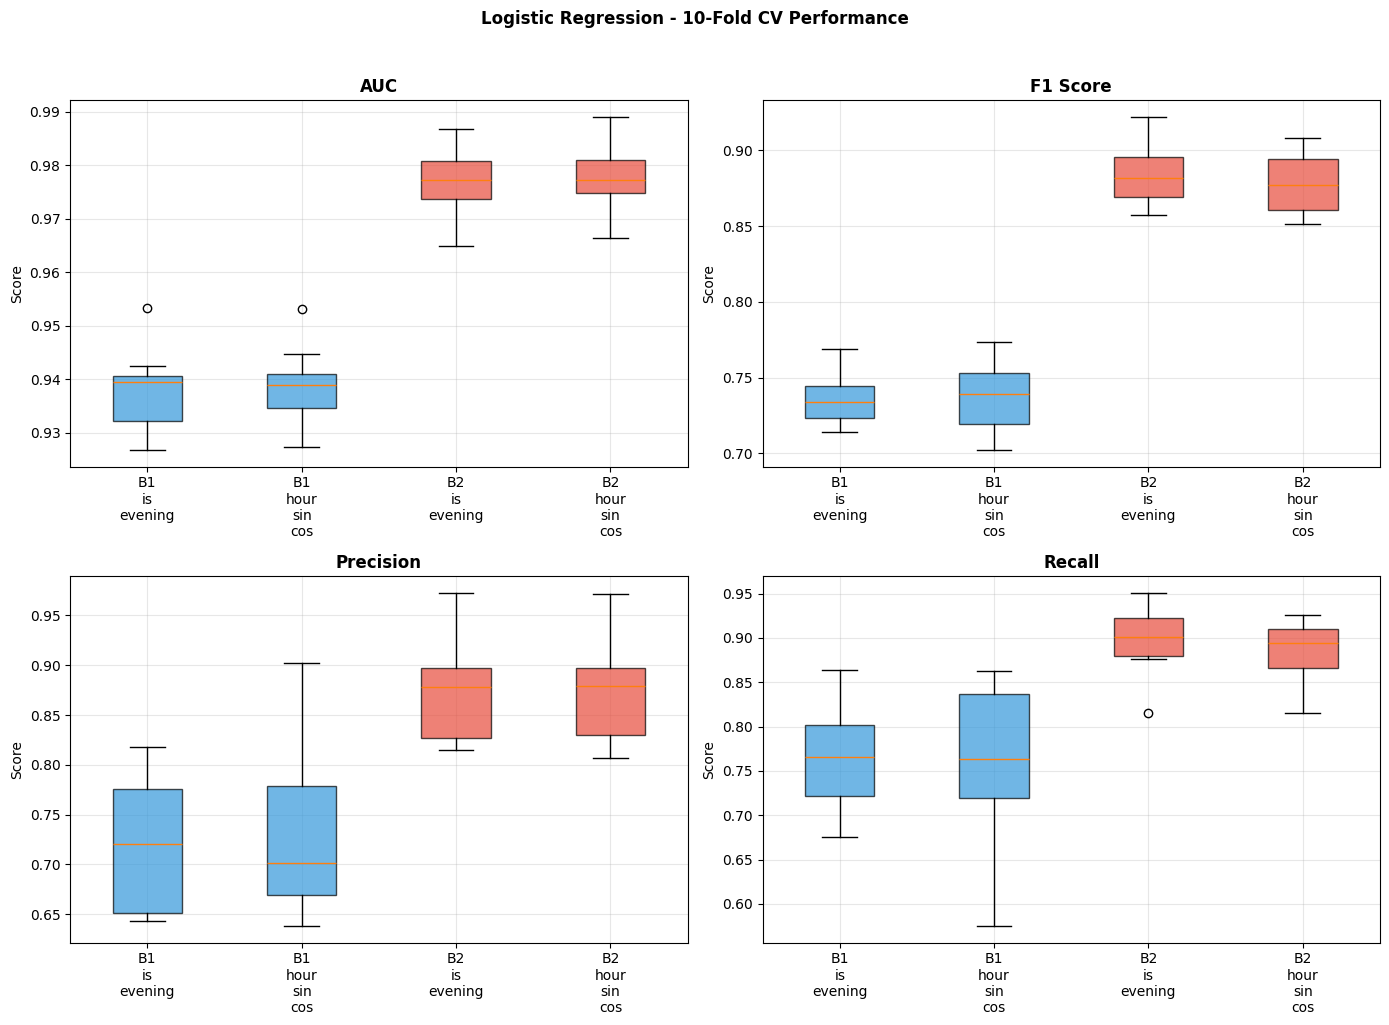

In [32]:
# Box plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['auc', 'f1', 'precision', 'recall']
titles = ['AUC', 'F1 Score', 'Precision', 'Recall']

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    # Prepare data for box plot
    data_to_plot = []
    labels_plot = []
    for model_key, fold_df in all_fold_metrics.items():
        data_to_plot.append(fold_df[metric].values)
        labels_plot.append(model_key.replace('_', '\n'))
    
    bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
    
    colors = ['#3498db', '#3498db', '#e74c3c', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('Logistic Regression - 10-Fold CV Performance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logreg_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

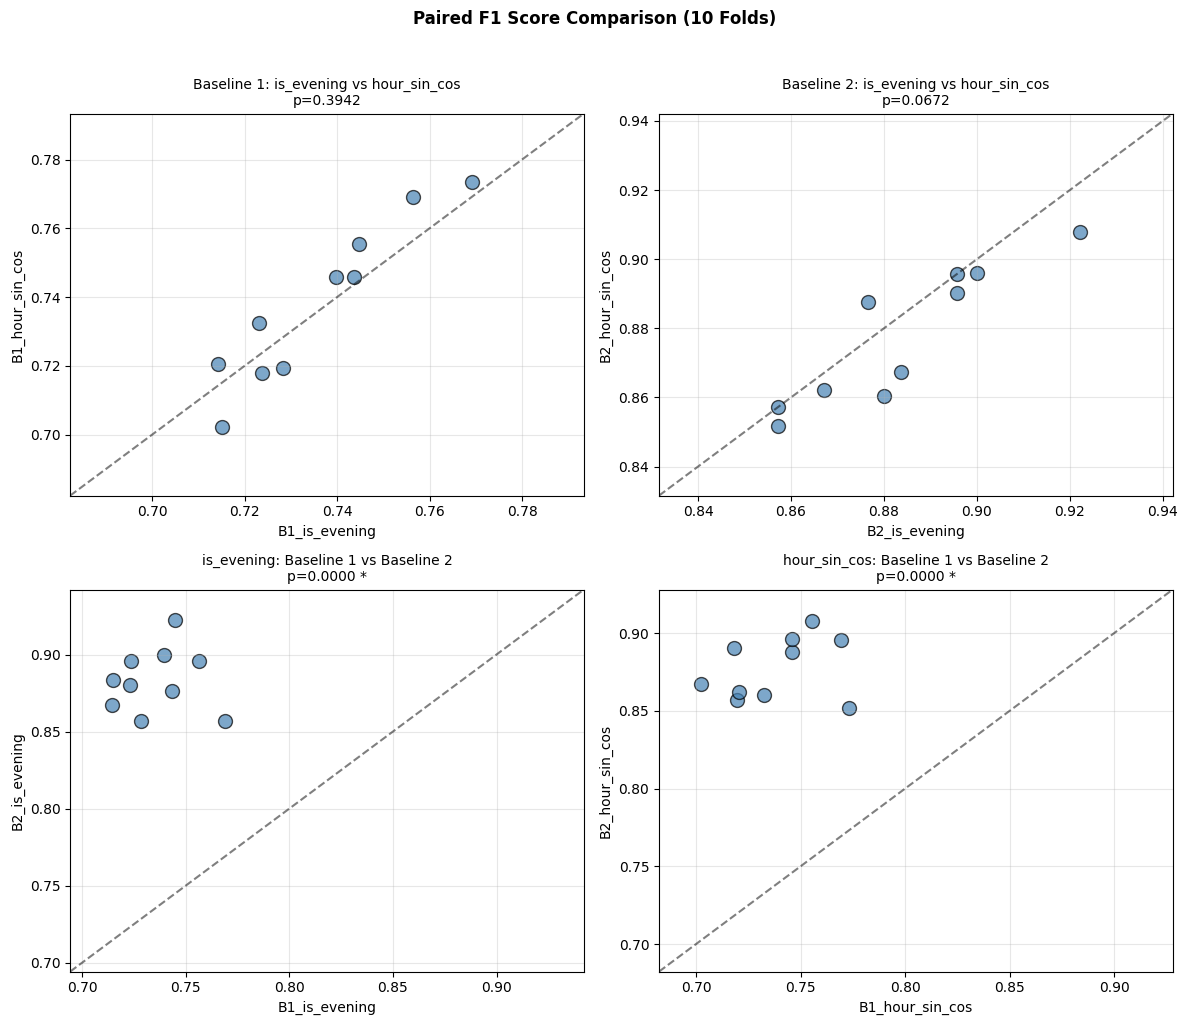

In [33]:
# Paired comparison plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model1, model2, desc) in zip(axes.flatten(), COMPARISON_PAIRS):
    scores1 = all_fold_metrics[model1]['f1'].values
    scores2 = all_fold_metrics[model2]['f1'].values
    
    # Scatter plot with diagonal line
    ax.scatter(scores1, scores2, alpha=0.7, s=100, c='steelblue', edgecolors='black')
    
    # Add diagonal line
    min_val = min(scores1.min(), scores2.min()) - 0.02
    max_val = max(scores1.max(), scores2.max()) + 0.02
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    # T-test result
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    sig_text = f"p={p_value:.4f}" + (" *" if p_value < 0.05 else "")
    
    ax.set_xlabel(model1)
    ax.set_ylabel(model2)
    ax.set_title(f"{desc}\n{sig_text}", fontsize=10)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)

plt.suptitle('Paired F1 Score Comparison (10 Folds)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'logreg_paired_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [34]:
print("="*70)
print("LOGISTIC REGRESSION TRAINING COMPLETE")
print("="*70)

print(f"\n📊 Models trained: {len(all_results)}")
for key, result in all_results.items():
    m = result['mean_metrics']
    print(f"  • {result['config']}: F1={m['f1_mean']:.4f}, AUC={m['auc_mean']:.4f}")

print(f"\n📁 Output files:")
print(f"  • Fold results: {TRAINED_DIR}")
print(f"  • Models: {MODEL_DIR}")
print(f"  • Figures: {FIGURES_DIR}")

# Best model
best_key = max(all_results.keys(), key=lambda k: all_results[k]['mean_metrics']['f1_mean'])
best_result = all_results[best_key]
print(f"\n🏆 Best model: {best_result['config']}")
print(f"   F1: {best_result['mean_metrics']['f1_mean']:.4f}")
print(f"   AUC: {best_result['mean_metrics']['auc_mean']:.4f}")

LOGISTIC REGRESSION TRAINING COMPLETE

📊 Models trained: 4
  • Baseline1 + is_evening: F1=0.7358, AUC=0.9377
  • Baseline1 + hour_sin_cos: F1=0.7383, AUC=0.9385
  • Baseline2 + is_evening: F1=0.8835, AUC=0.9765
  • Baseline2 + hour_sin_cos: F1=0.8776, AUC=0.9770

📁 Output files:
  • Fold results: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion
  • Models: d:\Vietnamese-Fake-News-Detection\model\early_fusion\logistic_regression
  • Figures: d:\Vietnamese-Fake-News-Detection\data\figures\training

🏆 Best model: Baseline2 + is_evening
   F1: 0.8835
   AUC: 0.9765
